# Missing Data Detection and Imputation

**Author:** Kaan Dogan  
**Context:** Guided data preprocessing exercise, refined and extended for portfolio presentation  
**Focus:** Missing-value diagnosis, appropriate treatment, and reproducible checks

This is a guided learning exercise rather than independent research. The portfolio version
preserves the original learning objective while improving reproducibility, methodology,
documentation, and code quality.

## Goal

This notebook uses three small tabular datasets to demonstrate that missing values should not
be treated mechanically. The appropriate response depends on the data type, the reason the value
is missing, and how the prepared data will be used.

The workflow will:

1. quantify missingness;
2. distinguish ordinary and structural missingness;
3. apply explicit imputation strategies;
4. retain missingness information when it may be useful; and
5. validate every transformation with assertions.

## Setup

Place the following files in the `data/` directory before running the notebook:

- `employees.csv`
- `Placement_Data_Full_Class.csv`
- `train.csv`

The repository excludes CSV files by default because redistribution rights must be checked
separately for each source. See `data/README.md` for details.

In [1]:
import os
from pathlib import Path

matplotlib_cache = Path(".cache/matplotlib")
matplotlib_cache.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(matplotlib_cache))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.impute import SimpleImputer

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)

In [2]:
REQUIRED_FILES = {
    "employees": "employees.csv",
    "placement": "Placement_Data_Full_Class.csv",
    "titanic": "train.csv",
}

candidate_data_dirs = [
    Path("data"),
    Path("missing-data-imputation/data"),
    Path("../missing-data-imputation/data"),
]

DATA_DIR = next(
    (
        folder
        for folder in candidate_data_dirs
        if all((folder / filename).exists() for filename in REQUIRED_FILES.values())
    ),
    None,
)

if DATA_DIR is None:
    expected = ", ".join(REQUIRED_FILES.values())
    raise FileNotFoundError(
        f"Could not find the required data files: {expected}. "
        "See data/README.md for setup instructions."
    )

print(f"Using data directory: {DATA_DIR}")

Using data directory: data


In [3]:
def missing_summary(frame: pd.DataFrame) -> pd.DataFrame:
    '''Return a bounded summary of columns containing missing values.'''
    missing_count = frame.isna().sum()
    summary = pd.DataFrame(
        {
            "missing_count": missing_count,
            "missing_pct": (missing_count / len(frame) * 100).round(2),
        }
    )
    return summary.loc[summary["missing_count"] > 0].sort_values(
        "missing_pct", ascending=False
    )


def plot_missingness(summary: pd.DataFrame, title: str) -> None:
    '''Plot missing-value percentages for a compact summary table.'''
    ax = sns.barplot(
        data=summary.reset_index(),
        x="missing_pct",
        y="index",
        color="#4C78A8",
    )
    ax.set(title=title, xlabel="Missing values (%)", ylabel="Column")
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", padding=3)
    plt.tight_layout()
    plt.show()

In [4]:
employees = pd.read_csv(DATA_DIR / REQUIRED_FILES["employees"])
placement = pd.read_csv(DATA_DIR / REQUIRED_FILES["placement"])
titanic = pd.read_csv(DATA_DIR / REQUIRED_FILES["titanic"])

dataset_inventory = pd.DataFrame(
    {
        "rows": [len(employees), len(placement), len(titanic)],
        "columns": [employees.shape[1], placement.shape[1], titanic.shape[1]],
        "duplicate_rows": [
            employees.duplicated().sum(),
            placement.duplicated().sum(),
            titanic.duplicated().sum(),
        ],
        "missing_cells": [
            employees.isna().sum().sum(),
            placement.isna().sum().sum(),
            titanic.isna().sum().sum(),
        ],
    },
    index=["Employees", "Placement", "Titanic"],
)
dataset_inventory

,rows,columns,duplicate_rows,missing_cells
Employees,1000,8,0,322
Placement,215,15,0,67
Titanic,891,12,0,866


## Steps

### 1. Employees: categorical missing values

The Employees dataset contains missing values in four categorical fields. A constant label is
used for names and gender so that the notebook does not infer personal attributes. The most
frequent category is used for `Senior Management` and `Team` only as a simple tutorial baseline.
In a real decision-making system, this assumption would need domain review.

,missing_count,missing_pct
Gender,145,14.5
First Name,67,6.7
Senior Management,67,6.7
Team,43,4.3


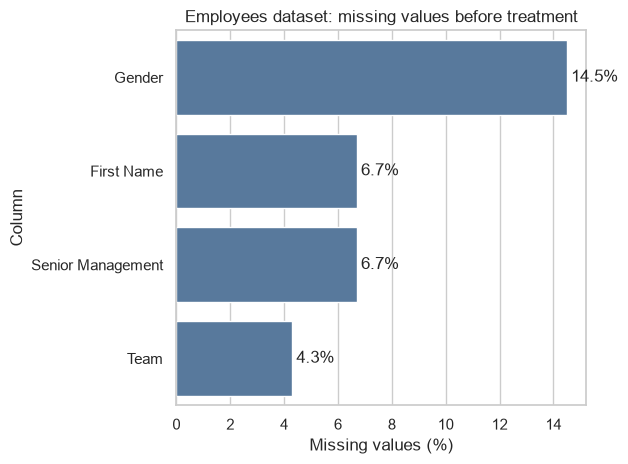

In [5]:
employees_missing = missing_summary(employees)
display(employees_missing)
plot_missingness(employees_missing, "Employees dataset: missing values before treatment")

In [6]:
employees_prepared = employees.copy()

employees_prepared["First Name"] = employees_prepared["First Name"].fillna("Unknown")
employees_prepared["Gender"] = employees_prepared["Gender"].fillna("Unknown")

for column in ["Senior Management", "Team"]:
    category_imputer = SimpleImputer(strategy="most_frequent")
    employees_prepared[[column]] = category_imputer.fit_transform(
        employees_prepared[[column]]
    )

employee_strategy = pd.DataFrame(
    {
        "column": ["First Name", "Gender", "Senior Management", "Team"],
        "strategy": [
            "Constant: Unknown",
            "Constant: Unknown",
            "Most frequent category",
            "Most frequent category",
        ],
        "missing_after": [
            employees_prepared[column].isna().sum()
            for column in ["First Name", "Gender", "Senior Management", "Team"]
        ],
    }
)
employee_strategy

,column,strategy,missing_after
0,First Name,Constant: Unknown,0
1,Gender,Constant: Unknown,0
2,Senior Management,Most frequent category,0
3,Team,Most frequent category,0


### 2. Placement: identify structural missingness before imputing

The original seminar demonstrated mean, median, and mode replacement for `salary`. However,
every missing salary belongs to a student whose status is `Not Placed`. The values are therefore
*not applicable*, rather than randomly missing. Replacing them with a typical placed salary would
create salaries that were never observed.

In [7]:
placement_missing = missing_summary(placement)
missing_salary_by_status = pd.crosstab(
    placement["status"],
    placement["salary"].isna(),
).rename(columns={False: "salary_present", True: "salary_missing"})

display(placement_missing)
display(missing_salary_by_status)

,missing_count,missing_pct
salary,67,31.16


salary,salary_present,salary_missing
status,,
Not Placed,0,67
Placed,148,0


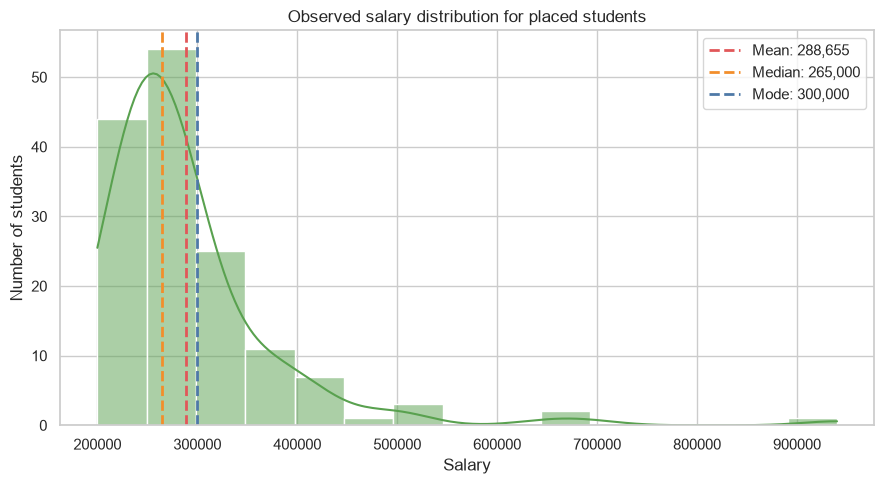

mean      288655.41
median    265000.00
mode      300000.00
Name: observed_salary, dtype: float64

In [8]:
observed_salary = placement.loc[placement["salary"].notna(), "salary"]
salary_statistics = pd.Series(
    {
        "mean": observed_salary.mean(),
        "median": observed_salary.median(),
        "mode": observed_salary.mode().iloc[0],
    },
    name="observed_salary",
).round(2)

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(observed_salary, bins=15, kde=True, ax=ax, color="#59A14F")
colours = {"mean": "#E15759", "median": "#F28E2B", "mode": "#4E79A7"}
for statistic, value in salary_statistics.items():
    ax.axvline(value, linestyle="--", linewidth=2, color=colours[statistic], label=f"{statistic.title()}: {value:,.0f}")
ax.set(
    title="Observed salary distribution for placed students",
    xlabel="Salary",
    ylabel="Number of students",
)
ax.legend()
plt.tight_layout()
plt.show()

salary_statistics

In [9]:
placement_prepared = placement.copy()
placement_prepared["salary_applicable"] = placement_prepared["status"].eq("Placed")

structural_missingness_check = (
    placement_prepared.loc[~placement_prepared["salary_applicable"], "salary"]
    .isna()
    .all()
)

pd.Series(
    {
        "missing_salary_rows": int(placement_prepared["salary"].isna().sum()),
        "all_missing_salaries_are_not_placed": structural_missingness_check,
        "central_tendency_imputation_applied": False,
    },
    name="placement_decision",
)

missing_salary_rows                       67
all_missing_salaries_are_not_placed     True
central_tendency_imputation_applied    False
Name: placement_decision, dtype: object

### 3. Titanic: median, most-frequent, and missingness indicators

`Age` is imputed with the median, while `Embarked` uses the most frequent category. `Cabin` is
missing for most passengers, so the notebook creates a `CabinKnown` indicator and drops the raw
high-cardinality field from the prepared table. This preserves whether cabin information was
available without inventing cabin numbers.

In a predictive workflow, imputers must be fitted on the training partition only and then applied
to validation or test data to prevent data leakage.

,missing_count,missing_pct
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


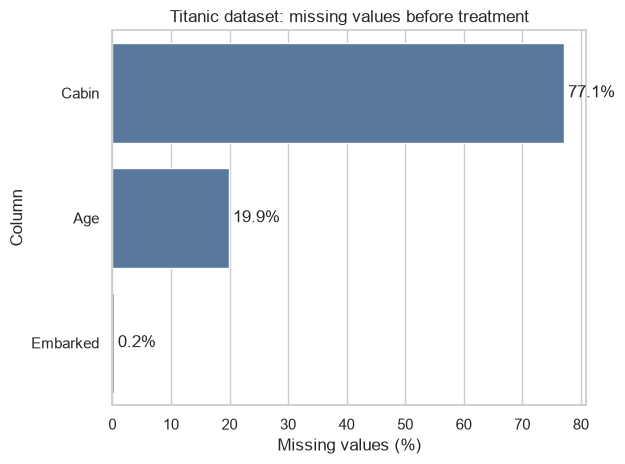

In [10]:
titanic_missing = missing_summary(titanic)
display(titanic_missing)
plot_missingness(titanic_missing, "Titanic dataset: missing values before treatment")

In [11]:
titanic_prepared = titanic.copy()
titanic_prepared["CabinKnown"] = titanic_prepared["Cabin"].notna().astype("int8")

age_imputer = SimpleImputer(strategy="median")
embarked_imputer = SimpleImputer(strategy="most_frequent")

titanic_prepared[["Age"]] = age_imputer.fit_transform(titanic_prepared[["Age"]])
titanic_prepared[["Embarked"]] = embarked_imputer.fit_transform(
    titanic_prepared[["Embarked"]]
)
titanic_prepared = titanic_prepared.drop(columns="Cabin")

imputation_values = pd.Series(
    {
        "Age median": float(age_imputer.statistics_[0]),
        "Embarked most frequent": embarked_imputer.statistics_[0],
        "Cabin known rate (%)": round(titanic["Cabin"].notna().mean() * 100, 2),
    },
    name="value",
)
imputation_values

Age median                28.0
Embarked most frequent       S
Cabin known rate (%)      22.9
Name: value, dtype: object

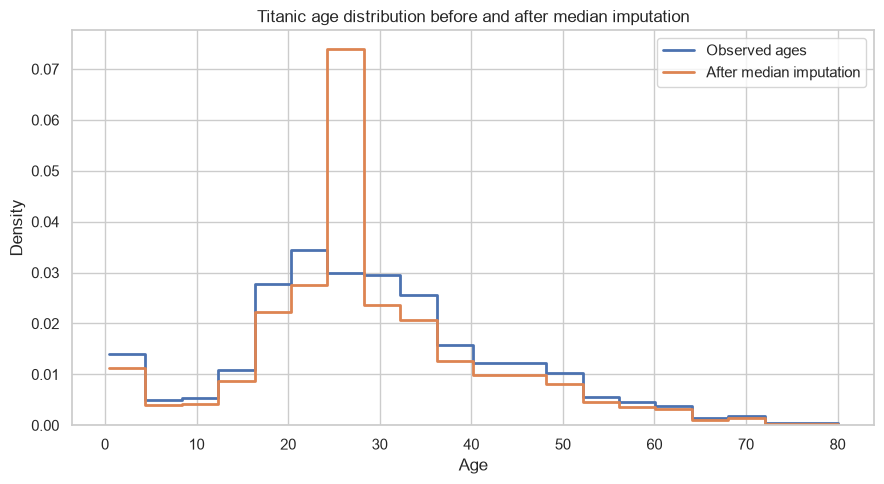

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(
    titanic["Age"].dropna(),
    bins=20,
    stat="density",
    element="step",
    fill=False,
    linewidth=2,
    label="Observed ages",
    ax=ax,
)
sns.histplot(
    titanic_prepared["Age"],
    bins=20,
    stat="density",
    element="step",
    fill=False,
    linewidth=2,
    label="After median imputation",
    ax=ax,
)
ax.set(
    title="Titanic age distribution before and after median imputation",
    xlabel="Age",
    ylabel="Density",
)
ax.legend()
plt.tight_layout()
plt.show()

## Checks

In [13]:
checks = {
    "Employees shape matches the seminar dataset": employees.shape == (1000, 8),
    "Placement shape matches the seminar dataset": placement.shape == (215, 15),
    "Titanic shape matches the seminar dataset": titanic.shape == (891, 12),
    "No duplicate rows in the source datasets": all(
        frame.duplicated().sum() == 0
        for frame in [employees, placement, titanic]
    ),
    "Employees prepared fields contain no missing values": employees_prepared[
        ["First Name", "Gender", "Senior Management", "Team"]
    ].isna().sum().sum() == 0,
    "Placement salary missingness is structural": structural_missingness_check,
    "Titanic prepared Age and Embarked contain no missing values": titanic_prepared[
        ["Age", "Embarked"]
    ].isna().sum().sum() == 0,
    "Titanic raw Cabin column was replaced by an indicator": (
        "Cabin" not in titanic_prepared.columns
        and "CabinKnown" in titanic_prepared.columns
    ),
}

validation_results = pd.Series(checks, name="passed").to_frame()
display(validation_results)

assert validation_results["passed"].all(), "One or more validation checks failed."
print("All validation checks passed.")

,passed
Employees shape matches the seminar dataset,True
Placement shape matches the seminar dataset,True
Titanic shape matches the seminar dataset,True
No duplicate rows in the source datasets,True
Employees prepared fields contain no missing values,True
Placement salary missingness is structural,True
Titanic prepared Age and Embarked contain no missing values,True
Titanic raw Cabin column was replaced by an indicator,True


All validation checks passed.


## Key Findings

- The Employees dataset contains **322 missing cells** across four categorical columns. The
  portfolio workflow avoids inferring missing names or gender values.
- The Placement dataset contains **67 missing salaries**, and all 67 belong to students marked
  `Not Placed`. Mean, median, or mode replacement would therefore be methodologically misleading.
- The Titanic dataset contains **177 missing ages**, **687 missing cabin values**, and **2 missing
  embarkation values**. The median age is **28**, and the most frequent embarkation category is
  **S**.
- A missing-value strategy should reflect why the value is absent, not only the column's data type.

## Limitations

- This notebook is a guided preprocessing exercise and does not train or evaluate a predictive model.
- The datasets are small, static teaching datasets and should not be treated as representative
  operational data.
- Most-frequent imputation is included as a simple baseline; it can reduce variation and introduce bias.
- The demonstration fits imputers on the complete Titanic training table. A production ML workflow
  must fit preprocessing only on the training partition.
- Dataset provenance and redistribution permissions must be verified independently before publishing
  any raw CSV files.

## Next Steps

1. Place these transformations inside a scikit-learn `Pipeline`.
2. Split modelling data before fitting any imputer to prevent leakage.
3. Compare baseline imputation with missingness indicators and model-based strategies.
4. Evaluate whether imputation changes downstream model performance or subgroup behaviour.

## Learning Resources

- [Scikit-learn: Imputation of missing values](https://scikit-learn.org/stable/modules/impute.html)
- [GeeksforGeeks: Working with missing data in Pandas](https://www.geeksforgeeks.org/working-with-missing-data-in-pandas/)
- [VitalFlux: Mean, median, and mode imputation](https://vitalflux.com/pandas-impute-missing-values-mean-median-mode/)